# Bloque 2

## **Parte A:** Preparacion de los datos

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, avg, count

spark = SparkSession.builder \
    .appName("bloque2_ml_Pedraza") \
    .getOrCreate()

In [2]:
df_clean = spark.read.csv(
    r"C:\Users\luisa\OneDrive\Documentos\proyecto_final_JosuePedraza\datos\df_clean_icfes.csv",
    header=True,
    inferSchema=True
)

df_clean.show(5)

+-------------+---------------+------------+---------------+-----------+-----------------+-------------------+-------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+-----------+------------------+
|COLE_BILINGUE|COLE_CALENDARIO|COLE_JORNADA|COLE_NATURALEZA|ESTU_GENERO|FAMI_CUARTOSHOGAR|FAMI_EDUCACIONMADRE|FAMI_EDUCACIONPADRE|FAMI_ESTRATOVIVIENDA|FAMI_PERSONASHOGAR|FAMI_TIENEAUTOMOVIL|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|FAMI_TIENELAVADORA|PUNT_INGLES|PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|PUNT_GLOBAL|ACCESO_TECNOLOGICO|
+-------------+---------------+------------+---------------+-----------+-----------------+-------------------+-------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-----

## 1. Crear variable de clasificación

Vamos a definir la variable de clasificación de acuerdo a buen desempeño y mal desempeño, teniendo en cuenta que para el año 2019 en los dos periodos evaluados, el puntaje de 320 era una aproximación del percentil 90 de los estudiantes. Entonces quienes tengan un puntaje mayor o igual a 320 seran considerados como estudiantes con buen desempeño en la prueba, para al final del ejercicio poder hacer una clasificacion de posibles alumnos que obtendran buenos resultados en las pruebas Saber 11.

In [3]:
df_clean = df_clean.withColumn(
    "DESEMPENO",
    
    when(col("PUNT_GLOBAL") >= 320, 1)
    .otherwise(0)
)

df_clean.groupBy("DESEMPENO").count().show()

+---------+------+
|DESEMPENO| count|
+---------+------+
|        1| 92506|
|        0|832110|
+---------+------+



In [4]:
df_base = df_clean.sample(fraction=0.15, seed=42).cache()

df_base.count()

138765

## 2. Pipeline y escala

In [5]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

variables_cualitativas = [
    "COLE_BILINGUE",
    "COLE_CALENDARIO",
    "COLE_JORNADA",
    "COLE_NATURALEZA",
    "ESTU_GENERO",
    "FAMI_CUARTOSHOGAR",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_PERSONASHOGAR",
    "FAMI_TIENEAUTOMOVIL",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENELAVADORA",
    "ACCESO_TECNOLOGICO"
]

variables_cuantitativas = [
    "PUNT_INGLES",
    "PUNT_MATEMATICAS",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES",
    "PUNT_LECTURA_CRITICA"
]

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + "_idx",
        handleInvalid="keep"
    )
    for c in variables_cualitativas
]

encoder = OneHotEncoder(
    inputCols=[c + "_idx" for c in variables_cualitativas],
    outputCols=[c + "_ohe" for c in variables_cualitativas]
)

assembler = VectorAssembler(
    inputCols=variables_cuantitativas + [c + "_ohe" for c in variables_cualitativas],
    outputCol="features_raw"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)

pipeline_preparacion = Pipeline(
    stages=indexers + [encoder, assembler, scaler]
)

modelo_preparacion = pipeline_preparacion.fit(df_base)

df_ml = modelo_preparacion.transform(df_base)

df_ml.select("DESEMPENO", "features").show(5, truncate=False)

+---------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|DESEMPENO|features                                                                                                                                                                                                                                                                                                                                                                                                                                          |
+---------+-----------------------------------------------------------------------------------------------

**Pipeline:**

Se uso StringIndexer para convertir las variables categóricas en representaciones numéricas, luego se uso el OneHotEncoder para evitar que la codificacion se tome como relaciones ordinales (las cuales no son ordinales solo codificadas), y por ultimo se aplico el VectorAssambler para que todas las variables fueran integradas en un solo vector de caracteristicas, lo cual es requerido por los modelos de SparkML.

**Justificación StandardScaler:**

Para el ejercicio se uso StandardScaler ya que visualmente las variables cuantitativas parecian cumplir con normalidad al tener distribuciones similares a la normal, no habuan escalar arbitrarias y presentaban pocos valores atipicos. Con el fin de preservar la estructura se uso esta estandarizacion, ya que centra las variables al rededor de la media y la desviacion estandar. 

## **Parte B:** Aprendizaje no supervisado

## 3. PCA

In [6]:
from pyspark.ml.feature import PCA

pca = PCA(
    k=20,
    inputCol="features",
    outputCol="pca_features"
)

modelo_pca = pca.fit(df_ml)

df_pca = modelo_pca.transform(df_ml)

varianza_explicada = modelo_pca.explainedVariance.toArray()

for i, var in enumerate(varianza_explicada):
    print(f"Componente {i+1}: {round(var * 100, 2)}%")

Componente 1: 9.86%
Componente 2: 7.29%
Componente 3: 4.02%
Componente 4: 3.49%
Componente 5: 3.32%
Componente 6: 2.56%
Componente 7: 2.47%
Componente 8: 2.36%
Componente 9: 2.24%
Componente 10: 2.09%
Componente 11: 1.94%
Componente 12: 1.88%
Componente 13: 1.83%
Componente 14: 1.77%
Componente 15: 1.73%
Componente 16: 1.7%
Componente 17: 1.68%
Componente 18: 1.67%
Componente 19: 1.65%
Componente 20: 1.63%


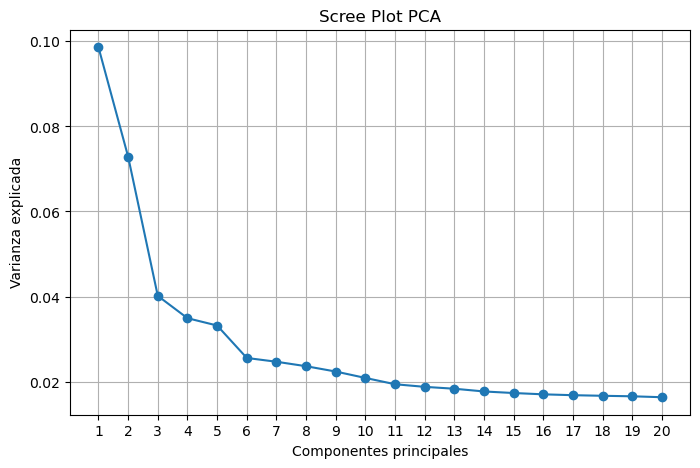

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(varianza_explicada)+1),
    varianza_explicada,
    marker='o'
)

plt.xlabel("Componentes principales")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot PCA")

plt.xticks(range(1, len(varianza_explicada)+1))

plt.grid(True)

plt.show()

**Justificación dimensiones a usar:**

Al hacer el PCA y tratar de escoger las dimensiones con el criterio de Kaiser, los eigenvalues eran superiores a 1 hasta en la dimension 20, por lo que se decidio hacer un analisis por el metodo del codo. De acuerdo al scree plot se considera usar 6 componentes, ya que a partir de dicha dimension se empieza a estabilizar la varianza explicada.

In [8]:
from pyspark.ml.feature import PCA

pca_final = PCA(
    k=6,
    inputCol="features",
    outputCol="pca_features"
)

modelo_pca_final = pca_final.fit(df_ml)

df_pca = modelo_pca_final.transform(df_ml)

df_pca.select("pca_features").show(5, truncate=False)

+------------------------------------------------------------------------------------------------------------------------+
|pca_features                                                                                                            |
+------------------------------------------------------------------------------------------------------------------------+
|[-2.244463534155097,1.2528892747092837,-7.656697782521032,-1.7003056511059973,-3.5820468594373587,-2.8759603484168617]  |
|[-6.82321105403658,-1.6428430398938054,-4.222677598097334,0.008281153518172824,-1.7865215657078795,-0.26059498146631804]|
|[-3.398287923906334,0.7593788055485315,-10.334521790320913,-0.8697457252086285,-4.161881074052978,0.4523456656619183]   |
|[1.5447927375770587,-8.601198122625144,-11.024075724482737,-5.741911241680428,2.8518043937824973,-3.4599016081953633]   |
|[2.2796759056918647,-14.177613846283945,-10.877247225259794,-2.8919182466063154,-4.1094676079958585,-2.6519003235211227]|
+---------------

## 4. K-Means

In [9]:
from pyspark.ml.clustering import KMeans

costos = []

for k in range(2, 11):
    
    kmeans = KMeans(
        featuresCol="pca_features",
        k=k,
        seed=42
    )
    
    modelo_kmeans = kmeans.fit(df_pca)
    
    costos.append(modelo_kmeans.summary.trainingCost)

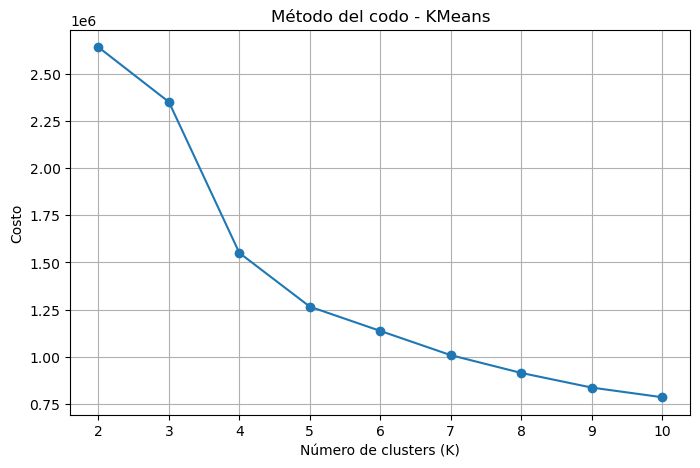

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(2,11), costos, marker='o')

plt.xlabel("Número de clusters (K)")
plt.ylabel("Costo")
plt.title("Método del codo - KMeans")

plt.grid(True)

plt.show()

El codo se observa al rededor de K=5 ya que a partir de ahi la curva empieza a aplanarse.

## 5. Analisis perfiles K-Means

In [11]:
from pyspark.ml.clustering import KMeans

kmeans_final = KMeans(
    featuresCol="pca_features",
    predictionCol="cluster",
    k=5,
    seed=42
)

modelo_final = kmeans_final.fit(df_pca)

df_clusters = modelo_final.transform(df_pca)

df_clusters.select("cluster").show(10)

+-------+
|cluster|
+-------+
|      3|
|      1|
|      3|
|      4|
|      4|
|      1|
|      3|
|      1|
|      0|
|      3|
+-------+
only showing top 10 rows


In [12]:
df_clusters.groupBy("cluster") \
    .count() \
    .orderBy("cluster") \
    .show()

+-------+-----+
|cluster|count|
+-------+-----+
|      0| 5306|
|      1|49732|
|      2|23378|
|      3|56320|
|      4| 4029|
+-------+-----+



### **Desempeño académico**

In [12]:
from pyspark.sql.functions import avg, count, round

perfil_academico_clusters = df_clusters.groupBy("cluster") \
    .agg(
        count("*").alias("N_ESTUDIANTES"),
        round(avg("PUNT_INGLES"), 2).alias("PROM_INGLES"),
        round(avg("PUNT_MATEMATICAS"), 2).alias("PROM_MATEMATICAS"),
        round(avg("PUNT_SOCIALES_CIUDADANAS"), 2).alias("PROM_SOCIALES"),
        round(avg("PUNT_C_NATURALES"), 2).alias("PROM_NATURALES"),
        round(avg("PUNT_LECTURA_CRITICA"), 2).alias("PROM_LECTURA"),
        round(avg("PUNT_GLOBAL"), 2).alias("PROM_GLOBAL")
    ) \
    .orderBy("PROM_GLOBAL", ascending=False)

perfil_academico_clusters.show(truncate=False)

+-------+-------------+-----------+----------------+-------------+--------------+------------+-----------+
|cluster|N_ESTUDIANTES|PROM_INGLES|PROM_MATEMATICAS|PROM_SOCIALES|PROM_NATURALES|PROM_LECTURA|PROM_GLOBAL|
+-------+-------------+-----------+----------------+-------------+--------------+------------+-----------+
|2      |152128       |63.48      |61.95           |58.05        |58.93         |61.93       |302.33     |
|3      |334248       |49.73      |51.57           |46.95        |49.05         |53.18       |250.76     |
|1      |27184        |46.32      |47.79           |44.68        |45.6          |50.53       |235.43     |
|4      |375944       |44.1       |47.64           |43.11        |45.47         |49.52       |231.26     |
|0      |35112        |44.05      |46.09           |42.88        |42.53         |49.21       |225.45     |
+-------+-------------+-----------+----------------+-------------+--------------+------------+-----------+



In [13]:
from pyspark.sql.functions import sum as spark_sum

total_cluster = df_clusters.groupBy("cluster") \
    .agg(count("*").alias("TOTAL_CLUSTER"))

perfil_contexto_clusters = df_clusters.groupBy(
    "cluster",
    "ACCESO_TECNOLOGICO"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "ACCESO_TECNOLOGICO")

perfil_contexto_clusters.show(truncate=False)

+-------+------------------+------+-------------+----------+
|cluster|ACCESO_TECNOLOGICO|N     |TOTAL_CLUSTER|PORCENTAJE|
+-------+------------------+------+-------------+----------+
|0      |Alto acceso       |158   |35112        |0.45      |
|0      |Bajo acceso       |34954 |35112        |99.55     |
|1      |Alto acceso       |16    |27184        |0.06      |
|1      |Bajo acceso       |27168 |27184        |99.94     |
|2      |Alto acceso       |140526|152128       |92.37     |
|2      |Bajo acceso       |11602 |152128       |7.63      |
|3      |Alto acceso       |312558|334248       |93.51     |
|3      |Bajo acceso       |21690 |334248       |6.49      |
|4      |Alto acceso       |2428  |375944       |0.65      |
|4      |Bajo acceso       |373516|375944       |99.35     |
+-------+------------------+------+-------------+----------+



In [14]:
perfil_estrato_clusters = df_clusters.groupBy(
    "cluster",
    "FAMI_ESTRATOVIVIENDA"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "FAMI_ESTRATOVIVIENDA")

perfil_estrato_clusters.show(100, truncate=False)

+-------+--------------------+------+-------------+----------+
|cluster|FAMI_ESTRATOVIVIENDA|N     |TOTAL_CLUSTER|PORCENTAJE|
+-------+--------------------+------+-------------+----------+
|0      |Estrato 1           |78    |35112        |0.22      |
|0      |Estrato 2           |104   |35112        |0.3       |
|0      |Estrato 3           |62    |35112        |0.18      |
|0      |Estrato 4           |30    |35112        |0.09      |
|0      |Estrato 5           |22    |35112        |0.06      |
|0      |Estrato 6           |12    |35112        |0.03      |
|0      |SIN                 |34784 |35112        |99.07     |
|0      |Sin Estrato         |20    |35112        |0.06      |
|1      |Estrato 1           |3472  |27184        |12.77     |
|1      |Estrato 2           |4694  |27184        |17.27     |
|1      |Estrato 3           |2916  |27184        |10.73     |
|1      |Estrato 4           |716   |27184        |2.63      |
|1      |Estrato 5           |244   |27184        |0.9 

In [15]:
perfil_naturaleza = df_clusters.groupBy(
    "cluster",
    "COLE_NATURALEZA"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "COLE_NATURALEZA")

perfil_naturaleza.show(truncate=False)

+-------+---------------+------+-------------+----------+
|cluster|COLE_NATURALEZA|N     |TOTAL_CLUSTER|PORCENTAJE|
+-------+---------------+------+-------------+----------+
|0      |NO OFICIAL     |9670  |35112        |27.54     |
|0      |OFICIAL        |25442 |35112        |72.46     |
|1      |NO OFICIAL     |8060  |27184        |29.65     |
|1      |OFICIAL        |19124 |27184        |70.35     |
|2      |NO OFICIAL     |130120|152128       |85.53     |
|2      |OFICIAL        |22008 |152128       |14.47     |
|3      |NO OFICIAL     |48130 |334248       |14.4      |
|3      |OFICIAL        |286118|334248       |85.6      |
|4      |NO OFICIAL     |54722 |375944       |14.56     |
|4      |OFICIAL        |321222|375944       |85.44     |
+-------+---------------+------+-------------+----------+



In [16]:
perfil_jornada = df_clusters.groupBy(
    "cluster",
    "COLE_JORNADA"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "COLE_JORNADA")

perfil_jornada.show(100, truncate=False)

+-------+------------+------+-------------+----------+
|cluster|COLE_JORNADA|N     |TOTAL_CLUSTER|PORCENTAJE|
+-------+------------+------+-------------+----------+
|0      |COMPLETA    |3292  |35112        |9.38      |
|0      |MAÑANA      |13458 |35112        |38.33     |
|0      |NOCHE       |5428  |35112        |15.46     |
|0      |SABATINA    |5706  |35112        |16.25     |
|0      |TARDE       |3918  |35112        |11.16     |
|0      |UNICA       |3310  |35112        |9.43      |
|1      |COMPLETA    |2894  |27184        |10.65     |
|1      |MAÑANA      |10956 |27184        |40.3      |
|1      |NOCHE       |3674  |27184        |13.52     |
|1      |SABATINA    |3994  |27184        |14.69     |
|1      |TARDE       |2980  |27184        |10.96     |
|1      |UNICA       |2686  |27184        |9.88      |
|2      |COMPLETA    |93062 |152128       |61.17     |
|2      |MAÑANA      |43774 |152128       |28.77     |
|2      |NOCHE       |1650  |152128       |1.08      |
|2      |S

In [17]:
perfil_bilingue = df_clusters.groupBy(
    "cluster",
    "COLE_BILINGUE"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "COLE_BILINGUE")

perfil_bilingue.show(truncate=False)

+-------+-------------+------+-------------+----------+
|cluster|COLE_BILINGUE|N     |TOTAL_CLUSTER|PORCENTAJE|
+-------+-------------+------+-------------+----------+
|0      |N            |29302 |35112        |83.45     |
|0      |S            |300   |35112        |0.85      |
|0      |SIN          |5510  |35112        |15.69     |
|1      |N            |22872 |27184        |84.14     |
|1      |S            |254   |27184        |0.93      |
|1      |SIN          |4058  |27184        |14.93     |
|2      |N            |122984|152128       |80.84     |
|2      |S            |1890  |152128       |1.24      |
|2      |SIN          |27254 |152128       |17.92     |
|3      |N            |292194|334248       |87.42     |
|3      |S            |1766  |334248       |0.53      |
|3      |SIN          |40288 |334248       |12.05     |
|4      |N            |323446|375944       |86.04     |
|4      |S            |4206  |375944       |1.12      |
|4      |SIN          |48292 |375944       |12.8

In [18]:
perfil_genero = df_clusters.groupBy(
    "cluster",
    "ESTU_GENERO"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "ESTU_GENERO")

perfil_genero.show(truncate=False)

+-------+-----------+------+-------------+----------+
|cluster|ESTU_GENERO|N     |TOTAL_CLUSTER|PORCENTAJE|
+-------+-----------+------+-------------+----------+
|0      |F          |19704 |35112        |56.12     |
|0      |M          |15408 |35112        |43.88     |
|1      |F          |13042 |27184        |47.98     |
|1      |M          |14142 |27184        |52.02     |
|2      |F          |76700 |152128       |50.42     |
|2      |M          |75428 |152128       |49.58     |
|3      |F          |175502|334248       |52.51     |
|3      |M          |158746|334248       |47.49     |
|4      |F          |218174|375944       |58.03     |
|4      |M          |157770|375944       |41.97     |
+-------+-----------+------+-------------+----------+



In [19]:
perfil_automovil = df_clusters.groupBy(
    "cluster",
    "FAMI_TIENEAUTOMOVIL"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "FAMI_TIENEAUTOMOVIL")

perfil_automovil.show(truncate=False)

+-------+-------------------+------+-------------+----------+
|cluster|FAMI_TIENEAUTOMOVIL|N     |TOTAL_CLUSTER|PORCENTAJE|
+-------+-------------------+------+-------------+----------+
|0      |No                 |27556 |35112        |78.48     |
|0      |SIN                |738   |35112        |2.1       |
|0      |Si                 |6818  |35112        |19.42     |
|1      |No                 |26    |27184        |0.1       |
|1      |SIN                |27152 |27184        |99.88     |
|1      |Si                 |6     |27184        |0.02      |
|2      |No                 |49116 |152128       |32.29     |
|2      |SIN                |176   |152128       |0.12      |
|2      |Si                 |102836|152128       |67.6      |
|3      |No                 |245830|334248       |73.55     |
|3      |SIN                |1138  |334248       |0.34      |
|3      |Si                 |87280 |334248       |26.11     |
|4      |No                 |344580|375944       |91.66     |
|4      

In [20]:
perfil_lavadora = df_clusters.groupBy(
    "cluster",
    "FAMI_TIENELAVADORA"
).agg(
    count("*").alias("N")
).join(
    total_cluster,
    on="cluster"
).withColumn(
    "PORCENTAJE",
    round((col("N") / col("TOTAL_CLUSTER")) * 100, 2)
).orderBy("cluster", "FAMI_TIENELAVADORA")

perfil_lavadora.show(truncate=False)

+-------+------------------+------+-------------+----------+
|cluster|FAMI_TIENELAVADORA|N     |TOTAL_CLUSTER|PORCENTAJE|
+-------+------------------+------+-------------+----------+
|0      |No                |9184  |35112        |26.16     |
|0      |SIN               |320   |35112        |0.91      |
|0      |Si                |25608 |35112        |72.93     |
|1      |No                |22    |27184        |0.08      |
|1      |SIN               |27098 |27184        |99.68     |
|1      |Si                |64    |27184        |0.24      |
|2      |No                |5422  |152128       |3.56      |
|2      |SIN               |60    |152128       |0.04      |
|2      |Si                |146646|152128       |96.4      |
|3      |No                |29690 |334248       |8.88      |
|3      |SIN               |420   |334248       |0.13      |
|3      |Si                |304138|334248       |90.99     |
|4      |No                |136772|375944       |36.38     |
|4      |SIN            

### **Análisis clústers**

* **Cluster 0:** Tiene el menor desempeño PROM_GLOBAL = 225.45. Aunque no todo el contexto familiar está perdido (es decir como dato sin informacion), el 99.07% aparece como SIN en estrato, y también tiene bajo acceso tecnológico 99.55%. Este clúster parece estar capturando tanto bajo rendimiento como un patrón fuerte de ausencia de información socioeconómica.

* **Cluster 1:** Tiene desempeño bajo-medio PROM_GLOBAL = 235.43, pero lo más importante es que varias variables familiares aparecen casi totalmente como SIN, por ejemplo automóvil 99.88% y lavadora 99.68%. Este clúster no debe interpretarse solo como perfil social real, sino como un grupo marcado por no respuesta o información incompleta.

* **Cluster 2:** Es el grupo con mejor rendimiento PROM_GLOBAL = 302.33. También tiene alto acceso tecnológico en el 92.37%, mayoría de colegios no oficiales 85.53%, jornada completa 61.17% y alta concentración en estratos 3, 4, 5 y 6. Este es claramente el perfil académico y socioeconómico más favorecido. *(Mayor desempeño y mejores condiciones)*

* **Cluster 3:** Tiene desempeño medio PROM_GLOBAL = 250.76. Aunque el 93.51% tiene alto acceso tecnológico, la mayoría pertenece a colegios oficiales 85.60% y se concentra en estratos 1, 2 y 3. Parece un grupo con acceso digital, pero con condiciones institucionales y socioeconómicas más moderadas.

* **Cluster 4:** Es el grupo más grande y tiene bajo desempeño PROM_GLOBAL = 231.26. El 99.35% está en bajo acceso tecnológico, el 85.44% en colegios oficiales y la posesión de bienes como automóvil o lavadora es menor. Este clúster representa un perfil de mayor vulnerabilidad educativa.

## 6. Modelo supervisado

In [13]:
df_modelo = df_ml.select("DESEMPENO", "features").cache()

train, test = df_modelo.randomSplit([0.8, 0.2], seed=42)

print("Train:", train.count())
print("Test:", test.count())

Train: 111236
Test: 27529


In [14]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="DESEMPENO",
    maxIter=20
)

modelo_lr = lr.fit(train)

pred_lr = modelo_lr.transform(test)

pred_lr.select("DESEMPENO", "prediction", "probability").show(5, truncate=False)

+---------+----------+-----------+
|DESEMPENO|prediction|probability|
+---------+----------+-----------+
|0        |0.0       |[1.0,0.0]  |
|0        |0.0       |[1.0,0.0]  |
|0        |0.0       |[1.0,0.0]  |
|0        |0.0       |[1.0,0.0]  |
|0        |0.0       |[1.0,0.0]  |
+---------+----------+-----------+
only showing top 5 rows


In [15]:
pred_lr_pd = pred_lr.select("DESEMPENO", "prediction", "probability").toPandas()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

y_true = pred_lr_pd["DESEMPENO"]
y_pred = pred_lr_pd["prediction"]
y_prob = pred_lr_pd["probability"].apply(lambda x: float(x[1]))

print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1: {f1_score(y_true, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_true, y_prob):.4f}")

confusion_matrix(y_true, y_pred)

Accuracy: 0.9995
Precision: 0.9967
Recall: 0.9982
F1: 0.9974
AUC: 1.0000


array([[24785,     9],
       [    5,  2730]], dtype=int64)

In [16]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="DESEMPENO",
    numTrees=30,
    maxDepth=6,
    seed=42
)

modelo_rf = rf.fit(train)

pred_rf = modelo_rf.transform(test)

pred_rf.select("DESEMPENO", "prediction", "probability").show(5, truncate=False)

+---------+----------+-----------------------------------------+
|DESEMPENO|prediction|probability                              |
+---------+----------+-----------------------------------------+
|0        |0.0       |[0.9774754483051686,0.02252455169483135] |
|0        |0.0       |[0.9774754483051686,0.02252455169483135] |
|0        |0.0       |[0.9774754483051686,0.02252455169483135] |
|0        |0.0       |[0.9869697403263344,0.013030259673665555]|
|0        |0.0       |[0.9756422736796047,0.024357726320395335]|
+---------+----------+-----------------------------------------+
only showing top 5 rows


In [17]:
pred_rf_pd = pred_rf.select("DESEMPENO", "prediction", "probability").toPandas()

y_true = pred_rf_pd["DESEMPENO"]
y_pred = pred_rf_pd["prediction"]
y_prob = pred_rf_pd["probability"].apply(lambda x: float(x[1]))

print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1: {f1_score(y_true, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_true, y_prob):.4f}")

confusion_matrix(y_true, y_pred)

Accuracy: 0.9752
Precision: 0.9849
Recall: 0.7623
F1: 0.8594
AUC: 0.9972


array([[24762,    32],
       [  650,  2085]], dtype=int64)